# Mumbai Air Pollution Forecasting with PyTorch LSTM

## Leakage-safe, multi-location PM2.5 forecasting

This notebook is a complete rewrite of the previous pipeline. It uses all location CSV files in the Mumbai dataset and trains a **multivariate PyTorch LSTM** to forecast the next PM2.5 observation.

### Improvements included

- Loads every CSV recursively from the Kaggle dataset
- Robust column-name standardization
- Automatic timestamp detection and parsing
- Treats negative pollutant concentrations as invalid measurements
- Keeps pollutant features instead of dropping them because of missingness
- Adds missingness indicators
- Adds cyclical time features
- Uses **chronological per-location train/validation/test splits**
- Uses **causal imputation only**: forward-fill from past observations, never interpolation from the future
- Uses training-derived fallback statistics only
- Preserves historical context across split boundaries without leaking future targets
- Validates NaN/Inf values before training
- Uses PyTorch LSTM with gradient clipping, LR scheduling and early stopping
- Evaluates MAE, RMSE, R², Median Absolute Error and sMAPE
- Avoids ordinary MAPE because PM2.5 can be close to zero
- Compares against a persistence baseline
- Produces overall and location-wise plots
- Saves the model, scalers, configuration and predictions

> **Target:** PM2.5. The source dataset does not appear to provide a consistently usable AQI column. This notebook therefore performs a scientifically cleaner task: next-step PM2.5 forecasting.


In [38]:
# ============================================================
# 0. IMPORTS AND REPRODUCIBILITY
# ============================================================

import re
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")


# -------------------------
# Reproducibility
# -------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)


PyTorch version: 2.10.0+cu128
Device: cuda


## 1. Configuration

In [39]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_DIR = Path(
    "/kaggle/input/datasets/gyaswanth297/air-quality-indexaqi-data-of-mumbai"
)

OUTPUT_DIR = Path(
    "./mumbai_pm25_lstm_output"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -------------------------
# Forecast configuration
# -------------------------

TARGET = "PM2.5"

SEQUENCE_LENGTH = 24
FORECAST_HORIZON = 1


# -------------------------
# Chronological split
# -------------------------

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# -------------------------
# Training configuration
# -------------------------

BATCH_SIZE = 256
MAX_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
EARLY_STOPPING_PATIENCE = 8


# -------------------------
# Model configuration
# -------------------------

HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.20


assert (
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO
) == 1.0


print("Data directory:", DATA_DIR)
print("Directory exists:", DATA_DIR.exists())
print("Target:", TARGET)
print("Sequence length:", SEQUENCE_LENGTH)
print("Forecast horizon:", FORECAST_HORIZON)


Data directory: /kaggle/input/datasets/gyaswanth297/air-quality-indexaqi-data-of-mumbai
Directory exists: True
Target: PM2.5
Sequence length: 24
Forecast horizon: 1


## 2. Load all CSV files

Each CSV is treated as a monitoring location. The filename is preserved as the location identifier.


In [40]:
# ============================================================
# 2. LOAD ALL CSV FILES
# ============================================================

csv_files = sorted(
    DATA_DIR.rglob("*.csv")
)

print("CSV files found:", len(csv_files))

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files found under: {DATA_DIR}"
    )


all_frames = []
file_summary = []


for file_path in csv_files:

    try:

        df = pd.read_csv(
            file_path
        )

        if df.empty:
            print(
                f"Skipping empty file: "
                f"{file_path.name}"
            )
            continue


        # Clean original column names
        df.columns = [
            str(col).strip()
            for col in df.columns
        ]


        # Use filename as location
        df["location"] = (
            file_path.stem
        )

        df["source_file"] = (
            file_path.name
        )

        all_frames.append(df)

        file_summary.append({
            "file": file_path.name,
            "location": file_path.stem,
            "rows": len(df),
            "columns": len(df.columns)
        })


    except Exception as e:

        print(
            f"Skipping {file_path.name}: {e}"
        )


if len(all_frames) == 0:
    raise ValueError(
        "No valid CSV files could be loaded."
    )


raw_data = pd.concat(
    all_frames,
    ignore_index=True,
    sort=False
)

file_summary_df = pd.DataFrame(
    file_summary
)


print("\nCombined dataset shape:")
print(raw_data.shape)

print("\nNumber of locations:")
print(raw_data["location"].nunique())

display(
    file_summary_df
)

display(
    raw_data.head()
)


CSV files found: 21

Combined dataset shape:
(1603208, 29)

Number of locations:
21


,file,location,rows,columns
0,BandraKurlaComplexMumbaiIITM.csv,BandraKurlaComplexMumbaiIITM,76475,27
1,BandraMumbaiMPCB.csv,BandraMumbaiMPCB,76363,24
2,BorivaliEastMumbaiIITM.csv,BorivaliEastMumbaiIITM,76364,19
3,BorivaliEastMumbaiMPCB.csv,BorivaliEastMumbaiMPCB,76365,25
4,ChakalaAndheriEastMumbaiIITM.csv,ChakalaAndheriEastMumbaiIITM,76365,27
5,ChhatrapatiShivajiIntlAirportT2MumbaiMPCB.csv,ChhatrapatiShivajiIntlAirportT2MumbaiMPCB,76321,25
6,ColabaMumbaiMPCB.csv,ColabaMumbaiMPCB,76389,25
7,DeonarMumbaiIITM.csv,DeonarMumbaiIITM,76321,26
8,KandivaliEastMumbaiMPCB.csv,KandivaliEastMumbaiMPCB,76321,26
9,KhindipadaBhandupWestMumbaiIITM.csv,KhindipadaBhandupWestMumbaiIITM,76321,26


,Unnamed: 0,From Date,To Date,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,...,SR,BP,Xylene,AT,RF,TOT-RF,location,source_file,Temp,VWS
0,0,2021-01-01 00:00:00,2021-01-01 00:15:00,147.26,175.93,16.23,61.72,45.30,79.76,4.68,...,NaN,953.2,0.0,21.84,0.0,0.0,BandraKurlaComplexMumbaiIITM,BandraKurlaComplexMumbaiIITM.csv,NaN,NaN
1,1,2021-01-01 00:15:00,2021-01-01 00:30:00,145.37,173.96,16.88,61.50,45.75,79.01,18.49,...,NaN,953.2,0.0,21.84,0.0,0.0,BandraKurlaComplexMumbaiIITM,BandraKurlaComplexMumbaiIITM.csv,NaN,NaN
2,2,2021-01-01 00:30:00,2021-01-01 00:45:00,156.71,186.12,22.71,62.99,51.15,84.96,17.62,...,NaN,953.2,0.0,22.01,0.0,0.0,BandraKurlaComplexMumbaiIITM,BandraKurlaComplexMumbaiIITM.csv,NaN,NaN
3,3,2021-01-01 00:45:00,2021-01-01 01:00:00,171.18,205.41,16.55,59.13,44.19,77.83,18.14,...,NaN,954.2,0.0,21.99,0.0,0.0,BandraKurlaComplexMumbaiIITM,BandraKurlaComplexMumbaiIITM.csv,NaN,NaN
4,4,2021-01-01 01:00:00,2021-01-01 01:15:00,183.17,219.31,20.39,59.87,47.66,81.63,18.69,...,NaN,954.9,0.0,22.04,0.0,0.0,BandraKurlaComplexMumbaiIITM,BandraKurlaComplexMumbaiIITM.csv,NaN,NaN


## 3. Standardize column names and parse timestamps

In [41]:
# ============================================================
# 3. STANDARDIZE COLUMN NAMES
# ============================================================

def normalize_column_name(name):

    name = str(name).strip().lower()

    name = (
        name
        .replace("μ", "u")
        .replace("µ", "u")
    )

    name = re.sub(
        r"[\s_\-]+",
        "",
        name
    )

    name = re.sub(
        r"[^a-z0-9.]",
        "",
        name
    )

    return name


COLUMN_ALIASES = {

    # PM2.5
    "pm2.5": "PM2.5",
    "pm25": "PM2.5",
    "pm2.5avg": "PM2.5",
    "pm25avg": "PM2.5",

    # PM10
    "pm10": "PM10",
    "pm10avg": "PM10",

    # Gases
    "no": "NO",
    "no2": "NO2",
    "nox": "NOx",
    "nh3": "NH3",
    "so2": "SO2",
    "co": "CO",
    "o3": "O3",

    # AQI
    "aqi": "AQI",
    "airqualityindex": "AQI",

    # Timestamps
    "fromdate": "timestamp",
    "date": "timestamp",
    "datetime": "timestamp",
    "timestamp": "timestamp",
    "datatime": "timestamp",

    "todate": "end_timestamp"
}


rename_map = {}

for column in raw_data.columns:

    normalized = normalize_column_name(
        column
    )

    if normalized in COLUMN_ALIASES:

        rename_map[column] = (
            COLUMN_ALIASES[normalized]
        )


data = raw_data.rename(
    columns=rename_map
).copy()


# Remove exact duplicate columns if aliases
# created duplicate names
data = data.loc[
    :,
    ~data.columns.duplicated()
]


print("Columns after standardization:")
print(data.columns.tolist())


Columns after standardization:
['Unnamed: 0', 'timestamp', 'end_timestamp', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone', 'Benzene', 'Toluene', 'Eth-Benzene', 'MP-Xylene', 'RH', 'WS', 'WD', 'SR', 'BP', 'Xylene', 'AT', 'RF', 'TOT-RF', 'location', 'source_file', 'Temp', 'VWS']


In [42]:
# ============================================================
# 3A. IDENTIFY AND PARSE TIMESTAMP
# ============================================================

if "timestamp" not in data.columns:

    raise ValueError(
        "Could not identify a timestamp column. "
        "Inspect raw_data.columns and update "
        "COLUMN_ALIASES."
    )


data["timestamp"] = pd.to_datetime(
    data["timestamp"],
    errors="coerce",
    dayfirst=True
)


invalid_timestamp_count = (
    data["timestamp"].isna().sum()
)

print(
    "Invalid timestamps:",
    invalid_timestamp_count
)


data = data.dropna(
    subset=["timestamp"]
).copy()


print(
    "Rows after timestamp cleaning:",
    len(data)
)

print(
    "Date range:",
    data["timestamp"].min(),
    "to",
    data["timestamp"].max()
)


Invalid timestamps: 961632
Rows after timestamp cleaning: 641576
Date range: 2021-01-01 00:00:00 to 2023-03-08 14:30:00


## 4. Identify pollutant columns and clean invalid values

Negative pollutant concentrations are physically invalid. They are converted to missing values before imputation.


In [43]:
# ============================================================
# 4. IDENTIFY POLLUTANTS
# ============================================================

CANDIDATE_POLLUTANTS = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "SO2",
    "CO",
    "O3"
]


POLLUTANT_FEATURES = [

    column

    for column
    in CANDIDATE_POLLUTANTS

    if (
        column in data.columns
        and data[column].notna().sum() > 0
    )
]


if TARGET not in POLLUTANT_FEATURES:

    raise ValueError(
        f"Target {TARGET} was not found."
    )


print("Available pollutant columns:")
print(POLLUTANT_FEATURES)


Available pollutant columns:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO']


In [44]:
# ============================================================
# 4A. CONVERT POLLUTANTS TO NUMERIC
# ============================================================

for column in POLLUTANT_FEATURES:

    data[column] = pd.to_numeric(
        data[column],
        errors="coerce"
    )


data = data.replace(
    [np.inf, -np.inf],
    np.nan
)


print("Numeric conversion complete.")


Numeric conversion complete.


In [45]:
# ============================================================
# 4B. NEGATIVE VALUES -> NaN
# ============================================================

negative_summary = []

for column in POLLUTANT_FEATURES:

    negative_count = int(
        (data[column] < 0).sum()
    )

    negative_summary.append({
        "feature": column,
        "negative_values": negative_count
    })


    # Pollutant concentration cannot be negative
    data.loc[
        data[column] < 0,
        column
    ] = np.nan


negative_summary_df = pd.DataFrame(
    negative_summary
)

display(
    negative_summary_df
)

print(
    "Negative pollutant values have been "
    "converted to NaN."
)


,feature,negative_values
0,PM2.5,0
1,PM10,0
2,NO,0
3,NO2,0
4,NOx,0
5,NH3,0
6,SO2,0
7,CO,0


Negative pollutant values have been converted to NaN.


Target: PM2.5

Target statistics before split:


count    499479.000000
mean         53.328241
std          48.511833
min           0.010000
25%          19.000000
50%          39.000000
75%          75.000000
max         995.350000
Name: PM2.5, dtype: float64

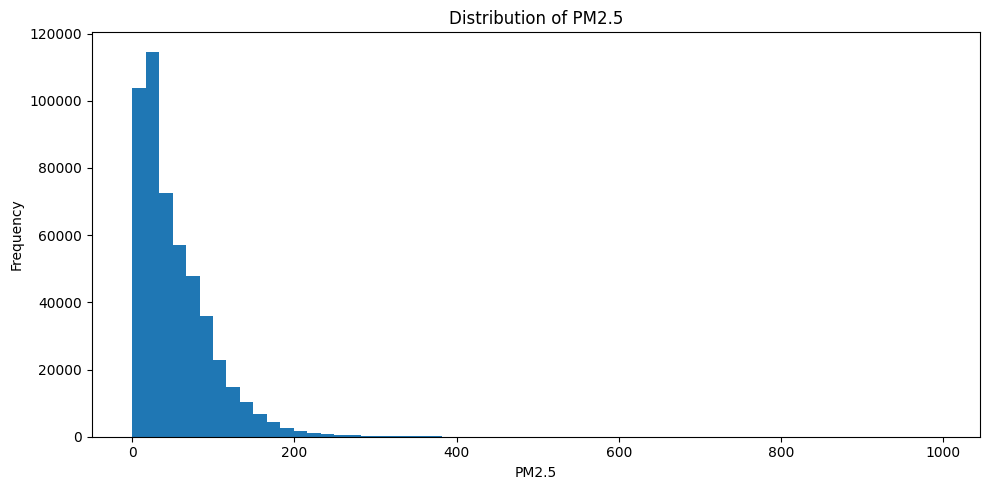

In [46]:
# ============================================================
# 4C. TARGET CHECK
# ============================================================

print("Target:", TARGET)

print("\nTarget statistics before split:")
display(
    data[TARGET].describe()
)

plt.figure(figsize=(10, 5))

plt.hist(
    data[TARGET].dropna(),
    bins=60
)

plt.title(
    f"Distribution of {TARGET}"
)

plt.xlabel(TARGET)
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## 5. Handle duplicate timestamps

If a location contains multiple measurements at the same timestamp, numeric pollutant values are aggregated using the median.


In [47]:
# ============================================================
# 5. HANDLE DUPLICATE LOCATION-TIMESTAMPS
# ============================================================

duplicate_count = int(
    data.duplicated(
        subset=[
            "location",
            "timestamp"
        ]
    ).sum()
)

print(
    "Duplicate location-timestamp rows:",
    duplicate_count
)


if duplicate_count > 0:

    numeric_columns = (
        POLLUTANT_FEATURES
    )


    other_columns = [
        "location",
        "timestamp"
    ]


    data = (
        data
        .groupby(
            other_columns,
            as_index=False
        )[numeric_columns]
        .median()
    )


print(
    "Shape after duplicate handling:",
    data.shape
)


Duplicate location-timestamp rows: 0
Shape after duplicate handling: (641576, 29)


## 6. Missingness analysis

Features are not dropped solely because some stations have missing values. The model receives both the imputed value and an explicit missingness indicator.


In [48]:
# ============================================================
# 6. MISSINGNESS ANALYSIS
# ============================================================

global_missing = (
    data[POLLUTANT_FEATURES]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)


print("Global missing percentage:")
display(
    global_missing.to_frame(
        "missing_percent"
    ).round(2)
)


location_missing = (
    data
    .groupby("location")[POLLUTANT_FEATURES]
    .apply(
        lambda x:
        x.isna().mean() * 100
    )
)


print(
    "Location-wise missing percentage:"
)

display(
    location_missing.round(1)
)


Global missing percentage:


,missing_percent
PM2.5,22.15
NOx,23.20
CO,24.51
NO2,24.75
NO,25.03
PM10,27.33
NH3,28.50
SO2,35.08


Location-wise missing percentage:


,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO
location,,,,,,,,
BandraKurlaComplexMumbaiIITM,15.5,16.3,23.1,22.0,22.0,22.9,21.5,15.8
BandraMumbaiMPCB,65.3,63.1,72.5,71.3,72.6,100.0,64.4,65.8
BorivaliEastMumbaiIITM,37.7,35.7,34.3,34.6,34.9,35.0,100.0,32.0
BorivaliEastMumbaiMPCB,24.7,36.2,28.4,29.5,28.2,28.5,47.2,41.6
ChakalaAndheriEastMumbaiIITM,14.5,14.8,25.5,25.9,25.6,26.1,15.6,12.3
ChhatrapatiShivajiIntlAirportT2MumbaiMPCB,12.1,4.2,20.0,21.2,19.1,23.1,16.4,16.9
ColabaMumbaiMPCB,37.8,36.8,38.2,38.0,36.4,36.3,43.7,35.0
DeonarMumbaiIITM,15.4,15.7,23.7,14.3,23.6,24.6,31.7,15.6
KandivaliEastMumbaiMPCB,25.1,35.6,18.9,14.7,6.6,15.3,27.0,27.0


## 7. Feature engineering

The model uses:
- Historical pollutant concentrations, including historical PM2.5
- Cyclical hour/day/month features
- Missingness indicators

The missingness indicators are calculated **before imputation**, preserving information about whether a sensor value was originally absent.


In [49]:
# ============================================================
# 7. SORT DATA
# ============================================================

data = (
    data
    .sort_values(
        ["location", "timestamp"]
    )
    .reset_index(drop=True)
)


print(
    "Locations:",
    data["location"].nunique()
)

print(
    "Rows:",
    len(data)
)


Locations: 21
Rows: 641576


In [50]:
# ============================================================
# 7A. TIME FEATURES
# ============================================================

data["hour"] = (
    data["timestamp"].dt.hour
)

data["day_of_week"] = (
    data["timestamp"].dt.dayofweek
)

data["month"] = (
    data["timestamp"].dt.month
)


data["hour_sin"] = np.sin(
    2 * np.pi
    * data["hour"]
    / 24
)

data["hour_cos"] = np.cos(
    2 * np.pi
    * data["hour"]
    / 24
)


data["dow_sin"] = np.sin(
    2 * np.pi
    * data["day_of_week"]
    / 7
)

data["dow_cos"] = np.cos(
    2 * np.pi
    * data["day_of_week"]
    / 7
)


data["month_sin"] = np.sin(
    2 * np.pi
    * (data["month"] - 1)
    / 12
)

data["month_cos"] = np.cos(
    2 * np.pi
    * (data["month"] - 1)
    / 12
)


TIME_FEATURES = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]


print("Time features:")
print(TIME_FEATURES)


Time features:
['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [51]:
# ============================================================
# 7B. MISSINGNESS INDICATORS
# ============================================================

MISSING_INDICATORS = []

for feature in POLLUTANT_FEATURES:

    indicator = (
        f"{feature}_missing"
    )

    data[indicator] = (
        data[feature]
        .isna()
        .astype(np.float32)
    )

    MISSING_INDICATORS.append(
        indicator
    )


FEATURES = (
    POLLUTANT_FEATURES
    + TIME_FEATURES
    + MISSING_INDICATORS
)


print(
    "Pollutant features:",
    len(POLLUTANT_FEATURES)
)

print(
    "Time features:",
    len(TIME_FEATURES)
)

print(
    "Missingness indicators:",
    len(MISSING_INDICATORS)
)

print(
    "Total model features:",
    len(FEATURES)
)

print("\nFinal feature list:")
print(FEATURES)


Pollutant features: 8
Time features: 6
Missingness indicators: 8
Total model features: 22

Final feature list:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'PM2.5_missing', 'PM10_missing', 'NO_missing', 'NO2_missing', 'NOx_missing', 'NH3_missing', 'SO2_missing', 'CO_missing']


## 8. Remove rows without the target and create chronological splits

Each location is split independently:

- First 70% → train
- Next 15% → validation
- Final 15% → test

No random splitting is used.


In [52]:
# ============================================================
# 8. REMOVE MISSING TARGETS
# ============================================================

rows_before = len(data)


data = data.dropna(
    subset=[TARGET]
).copy()


rows_after = len(data)


print(
    "Rows removed due to missing target:",
    rows_before - rows_after
)

print(
    "Remaining rows:",
    rows_after
)


Rows removed due to missing target: 142097
Remaining rows: 499479


In [53]:
# ============================================================
# 8A. ASSIGN CHRONOLOGICAL SPLITS
# ============================================================

split_parts = []
split_summary = []

minimum_rows = (
    SEQUENCE_LENGTH
    + FORECAST_HORIZON
    + 30
)


for location, group in data.groupby(
    "location",
    sort=False
):

    group = (
        group
        .sort_values("timestamp")
        .reset_index(drop=True)
        .copy()
    )


    n = len(group)


    if n < minimum_rows:

        print(
            f"Skipping {location}: "
            f"{n} rows "
            f"(minimum required: "
            f"{minimum_rows})"
        )

        continue


    train_end = int(
        n * TRAIN_RATIO
    )

    val_end = int(
        n
        * (
            TRAIN_RATIO
            + VAL_RATIO
        )
    )


    group["split"] = "test"

    group.loc[
        :train_end - 1,
        "split"
    ] = "train"

    group.loc[
        train_end:val_end - 1,
        "split"
    ] = "val"


    split_parts.append(group)


    split_summary.append({
        "location": location,
        "total": n,
        "train": int(
            (group["split"] == "train").sum()
        ),
        "validation": int(
            (group["split"] == "val").sum()
        ),
        "test": int(
            (group["split"] == "test").sum()
        )
    })


if len(split_parts) == 0:

    raise ValueError(
        "No location contains enough rows."
    )


data = pd.concat(
    split_parts,
    ignore_index=True
)


split_summary_df = pd.DataFrame(
    split_summary
)


display(
    split_summary_df
)


print(
    data["split"]
    .value_counts()
)


,location,total,train,validation,test
0,BandraKurlaComplexMumbaiIITM,25918,18142,3888,3888
1,BandraMumbaiMPCB,10600,7419,1591,1590
2,BorivaliEastMumbaiIITM,19044,13330,2857,2857
3,BorivaliEastMumbaiMPCB,23025,16117,3454,3454
4,ChakalaAndheriEastMumbaiIITM,26151,18305,3923,3923
5,ChhatrapatiShivajiIntlAirportT2MumbaiMPCB,26839,18787,4026,4026
6,ColabaMumbaiMPCB,19033,13323,2855,2855
7,DeonarMumbaiIITM,25819,18073,3873,3873
8,KandivaliEastMumbaiMPCB,22864,16004,3430,3430
9,KhindipadaBhandupWestMumbaiIITM,28732,20112,4310,4310


split
train    349625
test      74928
val       74926
Name: count, dtype: int64


## 9. Leakage-safe causal imputation

This section is intentionally strict.

### What is NOT used
- Linear interpolation
- Backward fill
- Any future observation

### What is used
For each location and pollutant:

1. Use the last known value from the past (`forward fill`)
2. For the beginning of a series, use a fallback statistic derived only from training data

Validation and test partitions inherit the final observed/imputed state from the previous partition. This gives the model realistic historical continuity without accessing future data.


In [54]:
# ============================================================
# 9. TRAINING-ONLY FALLBACK MEDIANS
# ============================================================

train_only_raw = data[
    data["split"] == "train"
].copy()


training_medians = (
    train_only_raw[POLLUTANT_FEATURES]
    .median()
)


print(
    "Training-only fallback medians:"
)

display(
    training_medians.to_frame(
        "median"
    )
)


Training-only fallback medians:


,median
PM2.5,37.83
PM10,99.00
NO,9.20
NO2,15.09
NOx,23.30
NH3,11.31
SO2,9.23
CO,0.68


In [55]:
# ============================================================
# 9A. CAUSAL IMPUTATION
# ============================================================

def causal_impute_location(
    group,
    pollutant_features,
    fallback_values
):
    """
    Strictly causal imputation.

    At each timestep:
    - use current observation if available
    - otherwise use the most recent past value
    - if no past value exists, use training median

    No backward fill.
    No interpolation.
    No future information.
    """

    group = (
        group
        .sort_values("timestamp")
        .copy()
    )


    for feature in pollutant_features:

        fallback = (
            fallback_values[feature]
        )

        values = []

        last_value = np.nan


        for value in group[feature]:

            if pd.notna(value):

                last_value = value
                values.append(value)

            else:

                if pd.notna(last_value):

                    values.append(
                        last_value
                    )

                else:

                    values.append(
                        fallback
                    )


        group[feature] = values


    return group


In [56]:
# ============================================================
# 9B. APPLY CAUSAL IMPUTATION
# ============================================================

imputed_parts = []


for location, group in data.groupby(
    "location",
    sort=False
):

    imputed_group = (
        causal_impute_location(
            group=group,
            pollutant_features=POLLUTANT_FEATURES,
            fallback_values=training_medians
        )
    )

    imputed_parts.append(
        imputed_group
    )


data_imputed = pd.concat(
    imputed_parts,
    ignore_index=True
)


data_imputed = (
    data_imputed
    .sort_values(
        ["location", "timestamp"]
    )
    .reset_index(drop=True)
)


print(
    "Causal imputation complete."
)


Causal imputation complete.


In [57]:
# ============================================================
# 9C. DATA QUALITY CHECK
# ============================================================

print("Missing values after causal imputation:")

remaining_missing = (
    data_imputed[POLLUTANT_FEATURES]
    .isna()
    .sum()
)

display(
    remaining_missing.to_frame(
        "missing_count"
    )
)


if remaining_missing.sum() > 0:

    raise ValueError(
        "Missing pollutant values remain "
        "after imputation."
    )


all_numeric_features = (
    FEATURES
    + [TARGET]
)


numeric_values = (
    data_imputed[
        all_numeric_features
    ]
    .to_numpy(
        dtype=np.float64
    )
)


nan_count = np.isnan(
    numeric_values
).sum()

inf_count = np.isinf(
    numeric_values
).sum()


print("NaN count:", nan_count)
print("Inf count:", inf_count)


assert nan_count == 0
assert inf_count == 0


print(
    "\n✓ Data passed NaN/Inf validation"
)


Missing values after causal imputation:


,missing_count
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
SO2,0
CO,0


NaN count: 0
Inf count: 0

✓ Data passed NaN/Inf validation


## 10. Scale features and target

Scalers are fitted using **training rows only**. Validation and test data are transformed with those same scalers.


In [58]:
# ============================================================
# 10. SPLIT DATAFRAMES
# ============================================================

train_df = data_imputed[
    data_imputed["split"] == "train"
].copy()

val_df = data_imputed[
    data_imputed["split"] == "val"
].copy()

test_df = data_imputed[
    data_imputed["split"] == "test"
].copy()


print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (349625, 47)
Validation shape: (74926, 47)
Test shape: (74928, 47)


In [59]:
# ============================================================
# 10A. FEATURE SCALING
# ============================================================

feature_scaler = StandardScaler()


feature_scaler.fit(
    train_df[FEATURES]
)


data_imputed[FEATURES] = (
    feature_scaler.transform(
        data_imputed[FEATURES]
    )
)


print(
    "Feature scaler fitted on training data only."
)


Feature scaler fitted on training data only.


In [60]:
# ============================================================
# 10B. TARGET SCALING
# ============================================================

target_scaler = StandardScaler()


target_scaler.fit(
    train_df[[TARGET]]
)


data_imputed["target_scaled"] = (
    target_scaler.transform(
        data_imputed[[TARGET]]
    )
)


print(
    "Target scaler fitted on training data only."
)


Target scaler fitted on training data only.


## 11. Create sequences without mixing locations

Sequences are generated from the complete chronological history of each location.

A sample is assigned to train/validation/test according to the **target timestamp**, not according to where the historical context begins.

This allows the first validation/test predictions to use legitimate observations from immediately before the split boundary while ensuring that the target itself remains in the correct held-out partition.


In [61]:
# ============================================================
# 11. CREATE LOCATION-SAFE SEQUENCES
# ============================================================

def create_sequences_with_target_split(
    df,
    features,
    sequence_length,
    horizon
):

    containers = {
        "train": {
            "X": [],
            "y": [],
            "meta": [],
            "baseline": []
        },
        "val": {
            "X": [],
            "y": [],
            "meta": [],
            "baseline": []
        },
        "test": {
            "X": [],
            "y": [],
            "meta": [],
            "baseline": []
        }
    }


    for location, group in df.groupby(
        "location",
        sort=False
    ):

        group = (
            group
            .sort_values("timestamp")
            .reset_index(drop=True)
        )


        X_values = (
            group[features]
            .to_numpy(
                dtype=np.float32
            )
        )


        y_scaled_values = (
            group["target_scaled"]
            .to_numpy(
                dtype=np.float32
            )
        )


        y_original_values = (
            group[TARGET]
            .to_numpy(
                dtype=np.float32
            )
        )


        timestamps = (
            group["timestamp"]
            .to_numpy()
        )


        splits = (
            group["split"]
            .to_numpy()
        )


        max_start = (
            len(group)
            - sequence_length
            - horizon
            + 1
        )


        for start in range(max_start):

            end = (
                start
                + sequence_length
            )


            target_index = (
                end
                + horizon
                - 1
            )


            target_split = (
                splits[target_index]
            )


            X_sequence = (
                X_values[start:end]
            )


            y_target = (
                y_scaled_values[target_index]
            )


            # Persistence baseline:
            # predict the last known PM2.5
            # from the input sequence.
            baseline_value = (
                y_original_values[end - 1]
            )


            containers[target_split]["X"].append(
                X_sequence
            )

            containers[target_split]["y"].append(
                y_target
            )

            containers[target_split]["baseline"].append(
                baseline_value
            )

            containers[target_split]["meta"].append({
                "location": location,
                "timestamp": timestamps[target_index],
                "split": target_split
            })


    output = {}


    for split_name, values in containers.items():

        output[split_name] = {

            "X": np.asarray(
                values["X"],
                dtype=np.float32
            ),

            "y": np.asarray(
                values["y"],
                dtype=np.float32
            ),

            "meta": pd.DataFrame(
                values["meta"]
            ),

            "baseline": np.asarray(
                values["baseline"],
                dtype=np.float32
            )
        }


    return output


In [62]:
# ============================================================
# 11A. GENERATE ALL SEQUENCES
# ============================================================

sequence_data = (
    create_sequences_with_target_split(
        df=data_imputed,
        features=FEATURES,
        sequence_length=SEQUENCE_LENGTH,
        horizon=FORECAST_HORIZON
    )
)


X_train = sequence_data["train"]["X"]
y_train = sequence_data["train"]["y"]
meta_train = sequence_data["train"]["meta"]


X_val = sequence_data["val"]["X"]
y_val = sequence_data["val"]["y"]
meta_val = sequence_data["val"]["meta"]


X_test = sequence_data["test"]["X"]
y_test = sequence_data["test"]["y"]
meta_test = sequence_data["test"]["meta"]


baseline_test = (
    sequence_data["test"]["baseline"]
)


print("Train sequences:", X_train.shape)
print("Validation sequences:", X_val.shape)
print("Test sequences:", X_test.shape)


Train sequences: (349121, 24, 22)
Validation sequences: (74926, 24, 22)
Test sequences: (74928, 24, 22)


In [63]:
# ============================================================
# 11B. VALIDATE SEQUENCES
# ============================================================

def validate_sequences(
    X,
    y,
    name
):

    print(f"\n{name}")

    print("X shape:", X.shape)
    print("y shape:", y.shape)

    print(
        "X NaN count:",
        np.isnan(X).sum()
    )

    print(
        "y NaN count:",
        np.isnan(y).sum()
    )

    print(
        "X Inf count:",
        np.isinf(X).sum()
    )

    print(
        "y Inf count:",
        np.isinf(y).sum()
    )


    assert len(X) > 0
    assert not np.isnan(X).any()
    assert not np.isnan(y).any()
    assert not np.isinf(X).any()
    assert not np.isinf(y).any()


validate_sequences(
    X_train,
    y_train,
    "TRAIN"
)

validate_sequences(
    X_val,
    y_val,
    "VALIDATION"
)

validate_sequences(
    X_test,
    y_test,
    "TEST"
)


print(
    "\n✓ All sequences are valid"
)



TRAIN
X shape: (349121, 24, 22)
y shape: (349121,)
X NaN count: 0
y NaN count: 0
X Inf count: 0
y Inf count: 0

VALIDATION
X shape: (74926, 24, 22)
y shape: (74926,)
X NaN count: 0
y NaN count: 0
X Inf count: 0
y Inf count: 0

TEST
X shape: (74928, 24, 22)
y shape: (74928,)
X NaN count: 0
y NaN count: 0
X Inf count: 0
y Inf count: 0

✓ All sequences are valid


## 12. PyTorch Dataset and DataLoaders

In [64]:
# ============================================================
# 12. PYTORCH DATASET
# ============================================================

class AirQualityDataset(Dataset):

    def __init__(
        self,
        X,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )


    def __len__(self):

        return len(self.X)


    def __getitem__(
        self,
        index
    ):

        return (
            self.X[index],
            self.y[index]
        )


In [65]:
# ============================================================
# 12A. DATALOADERS
# ============================================================

train_dataset = AirQualityDataset(
    X_train,
    y_train
)

val_dataset = AirQualityDataset(
    X_val,
    y_val
)

test_dataset = AirQualityDataset(
    X_test,
    y_test
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)


Train batches: 1364
Validation batches: 293
Test batches: 293


## 13. Define the PyTorch LSTM

In [66]:
# ============================================================
# 13. LSTM MODEL
# ============================================================

class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        dropout
    ):

        super().__init__()


        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=(
                dropout
                if num_layers > 1
                else 0.0
            )
        )


        self.regressor = nn.Sequential(

            nn.Linear(
                hidden_size,
                64
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                64,
                1
            )
        )


    def forward(
        self,
        x
    ):

        lstm_output, _ = self.lstm(
            x
        )


        last_hidden = (
            lstm_output[:, -1, :]
        )


        output = self.regressor(
            last_hidden
        )


        return output.squeeze(1)


In [67]:
# ============================================================
# 13A. INITIALIZE MODEL
# ============================================================

model = LSTMRegressor(

    input_size=len(FEATURES),

    hidden_size=HIDDEN_SIZE,

    num_layers=NUM_LAYERS,

    dropout=DROPOUT

).to(DEVICE)


criterion = nn.MSELoss()


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=3
    )
)


print(model)


total_parameters = sum(

    parameter.numel()

    for parameter

    in model.parameters()

    if parameter.requires_grad
)


print(
    "\nTrainable parameters:",
    f"{total_parameters:,}"
)


LSTMRegressor(
  (lstm): LSTM(22, 128, num_layers=2, batch_first=True, dropout=0.2)
  (regressor): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 218,241


## 14. Training functions

In [68]:
# ============================================================
# 14. TRAIN / VALIDATE ONE EPOCH
# ============================================================

def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):

    is_training = (
        optimizer is not None
    )


    if is_training:

        model.train()

    else:

        model.eval()


    total_loss = 0.0
    total_mae = 0.0
    total_samples = 0


    with torch.set_grad_enabled(
        is_training
    ):

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(
                DEVICE,
                non_blocking=True
            )

            y_batch = y_batch.to(
                DEVICE,
                non_blocking=True
            )


            if is_training:

                optimizer.zero_grad(
                    set_to_none=True
                )


            predictions = model(
                X_batch
            )


            loss = criterion(
                predictions,
                y_batch
            )


            # Safety check
            if not torch.isfinite(loss):

                raise ValueError(
                    "Non-finite loss detected. "
                    "Check input data."
                )


            if is_training:

                loss.backward()


                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )


                optimizer.step()


            batch_size = (
                X_batch.size(0)
            )


            total_loss += (
                loss.item()
                * batch_size
            )


            total_mae += (
                torch.abs(
                    predictions
                    - y_batch
                )
                .sum()
                .item()
            )


            total_samples += (
                batch_size
            )


    average_loss = (
        total_loss
        / total_samples
    )

    average_mae = (
        total_mae
        / total_samples
    )


    return (
        average_loss,
        average_mae
    )


## 15. Train with early stopping

In [69]:
# ============================================================
# 15. TRAIN MODEL
# ============================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "train_mae": [],
    "val_mae": []
}


best_val_loss = float("inf")

best_model_state = None

patience_counter = 0


for epoch in range(
    MAX_EPOCHS
):

    train_loss, train_mae = (
        run_epoch(

            model=model,

            loader=train_loader,

            criterion=criterion,

            optimizer=optimizer
        )
    )


    val_loss, val_mae = (
        run_epoch(

            model=model,

            loader=val_loader,

            criterion=criterion,

            optimizer=None
        )
    )


    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_mae"].append(
        train_mae
    )

    history["val_mae"].append(
        val_mae
    )


    scheduler.step(
        val_loss
    )


    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    print(

        f"Epoch [{epoch + 1:02d}/{MAX_EPOCHS}] | "

        f"Train Loss: {train_loss:.5f} | "

        f"Val Loss: {val_loss:.5f} | "

        f"Train MAE: {train_mae:.5f} | "

        f"Val MAE: {val_mae:.5f} | "

        f"LR: {current_lr:.6f}"
    )


    if val_loss < best_val_loss:

        best_val_loss = val_loss


        best_model_state = {

            key: value.detach()
            .cpu()
            .clone()

            for key, value

            in model.state_dict().items()
        }


        patience_counter = 0


    else:

        patience_counter += 1


        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                "\nEarly stopping triggered."
            )

            break


if best_model_state is None:

    raise RuntimeError(
        "Training did not produce "
        "a valid model state."
    )


model.load_state_dict(
    best_model_state
)


print(
    "\nBest validation loss:",
    best_val_loss
)


Epoch [01/50] | Train Loss: 0.01505 | Val Loss: 0.00018 | Train MAE: 0.07892 | Val MAE: 0.00969 | LR: 0.001000
Epoch [02/50] | Train Loss: 0.00375 | Val Loss: 0.00008 | Train MAE: 0.04806 | Val MAE: 0.00431 | LR: 0.001000
Epoch [03/50] | Train Loss: 0.00096 | Val Loss: 0.00007 | Train MAE: 0.02369 | Val MAE: 0.00375 | LR: 0.001000
Epoch [04/50] | Train Loss: 0.00013 | Val Loss: 0.00007 | Train MAE: 0.00778 | Val MAE: 0.00246 | LR: 0.001000
Epoch [05/50] | Train Loss: 0.00004 | Val Loss: 0.00006 | Train MAE: 0.00358 | Val MAE: 0.00203 | LR: 0.001000
Epoch [06/50] | Train Loss: 0.00004 | Val Loss: 0.00007 | Train MAE: 0.00336 | Val MAE: 0.00224 | LR: 0.001000
Epoch [07/50] | Train Loss: 0.00004 | Val Loss: 0.00007 | Train MAE: 0.00335 | Val MAE: 0.00335 | LR: 0.001000
Epoch [08/50] | Train Loss: 0.00004 | Val Loss: 0.00006 | Train MAE: 0.00327 | Val MAE: 0.00181 | LR: 0.001000
Epoch [09/50] | Train Loss: 0.00004 | Val Loss: 0.00006 | Train MAE: 0.00316 | Val MAE: 0.00175 | LR: 0.001000
E

## 16. Plot training curves

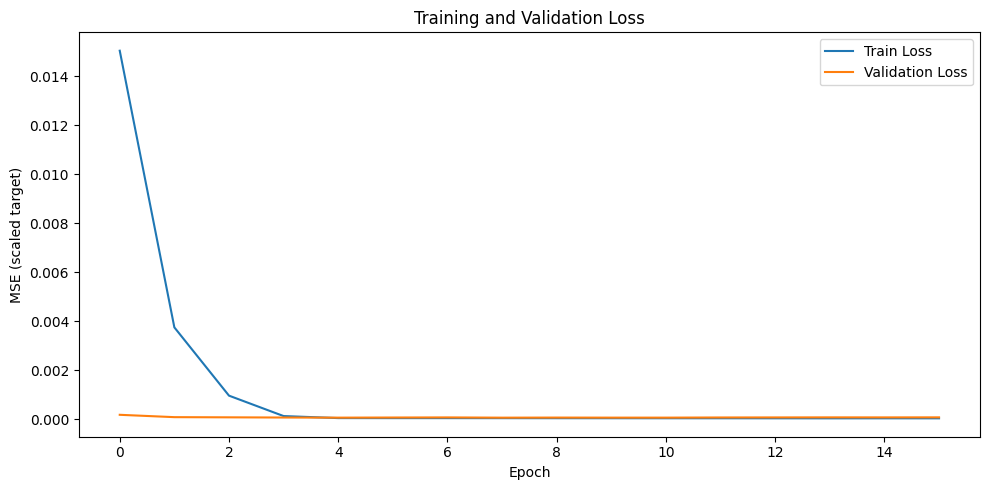

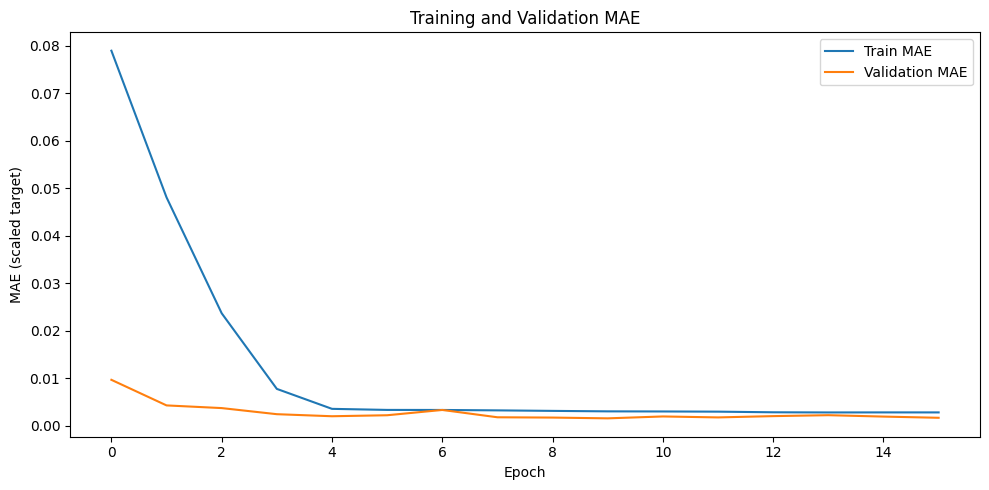

In [70]:
# ============================================================
# 16. TRAINING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE (scaled target)")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    history["train_mae"],
    label="Train MAE"
)

plt.plot(
    history["val_mae"],
    label="Validation MAE"
)

plt.title(
    "Training and Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (scaled target)")
plt.legend()

plt.tight_layout()
plt.show()


## 17. Generate test predictions

In [71]:
# ============================================================
# 17. TEST PREDICTIONS
# ============================================================

model.eval()


prediction_batches = []


with torch.no_grad():

    for X_batch, _ in test_loader:

        X_batch = X_batch.to(
            DEVICE,
            non_blocking=True
        )


        predictions = model(
            X_batch
        )


        prediction_batches.append(
            predictions.cpu().numpy()
        )


y_pred_scaled = np.concatenate(
    prediction_batches
).reshape(-1, 1)


y_true_scaled = (
    y_test
    .reshape(-1, 1)
)


# Convert back to original PM2.5 units
y_pred = (
    target_scaler
    .inverse_transform(
        y_pred_scaled
    )
    .flatten()
)


y_true = (
    target_scaler
    .inverse_transform(
        y_true_scaled
    )
    .flatten()
)


print(
    "Predictions:",
    len(y_pred)
)

print(
    "Actual values:",
    len(y_true)
)


Predictions: 74928
Actual values: 74928


## 18. Evaluation metrics

In [72]:
# ============================================================
# 18. METRIC FUNCTIONS
# ============================================================

def calculate_smape(
    y_true,
    y_pred
):
    """
    Symmetric MAPE.

    More robust than ordinary MAPE when
    targets are close to zero.
    """

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )


    mask = (
        denominator > 1e-8
    )


    if mask.sum() == 0:

        return np.nan


    return (
        100
        * np.mean(

            2
            * np.abs(
                y_pred[mask]
                - y_true[mask]
            )

            / denominator[mask]
        )
    )


In [73]:
# ============================================================
# 18A. LSTM METRICS
# ============================================================

lstm_mae = mean_absolute_error(
    y_true,
    y_pred
)


lstm_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)


lstm_r2 = r2_score(
    y_true,
    y_pred
)


lstm_median_ae = (
    median_absolute_error(
        y_true,
        y_pred
    )
)


lstm_smape = calculate_smape(
    y_true,
    y_pred
)


metrics_df = pd.DataFrame({

    "Metric": [

        "MAE",

        "RMSE",

        "R²",

        "Median Absolute Error",

        "sMAPE (%)"
    ],

    "Value": [

        lstm_mae,

        lstm_rmse,

        lstm_r2,

        lstm_median_ae,

        lstm_smape
    ]
})


display(
    metrics_df.round(4)
)


,Metric,Value
0,MAE,0.1386
1,RMSE,0.4282
2,R²,0.8839
3,Median Absolute Error,0.0705
4,sMAPE (%),28.1047


## 19. Persistence baseline

The persistence baseline predicts:

\[
PM2.5(t) = PM2.5(t-1)
\]

This is essential. A forecasting model should be judged against a simple baseline, not only by its absolute metrics.


In [74]:
# ============================================================
# 19. PERSISTENCE BASELINE
# ============================================================

baseline_mae = mean_absolute_error(
    y_true,
    baseline_test
)


baseline_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        baseline_test
    )
)


baseline_r2 = r2_score(
    y_true,
    baseline_test
)


baseline_median_ae = (
    median_absolute_error(
        y_true,
        baseline_test
    )
)


baseline_smape = calculate_smape(
    y_true,
    baseline_test
)


comparison_df = pd.DataFrame({

    "Model": [

        "PyTorch LSTM",

        "Persistence Baseline"
    ],

    "MAE": [

        lstm_mae,

        baseline_mae
    ],

    "RMSE": [

        lstm_rmse,

        baseline_rmse
    ],

    "R²": [

        lstm_r2,

        baseline_r2
    ],

    "Median AE": [

        lstm_median_ae,

        baseline_median_ae
    ],

    "sMAPE (%)": [

        lstm_smape,

        baseline_smape
    ]
})


display(
    comparison_df.round(4)
)


if lstm_mae < baseline_mae:

    print(
        "✓ LSTM beats the persistence "
        "baseline on MAE."
    )

else:

    print(
        "⚠ Persistence baseline beats "
        "the LSTM on MAE."
    )


,Model,MAE,RMSE,R²,Median AE,sMAPE (%)
0,PyTorch LSTM,0.1386,0.4282,0.8839,0.0705,28.104700
1,Persistence Baseline,0.1248,0.4550,0.8689,0.0331,20.320801


⚠ Persistence baseline beats the LSTM on MAE.


## 20. Build prediction results dataframe

In [75]:
# ============================================================
# 20. RESULTS DATAFRAME
# ============================================================

results = meta_test.copy()


results["actual"] = (
    y_true
)

results["predicted"] = (
    y_pred
)

results["persistence"] = (
    baseline_test
)

results["residual"] = (
    results["actual"]
    - results["predicted"]
)


results["absolute_error"] = (
    np.abs(
        results["residual"]
    )
)


results = (
    results
    .sort_values(
        ["location", "timestamp"]
    )
    .reset_index(drop=True)
)


display(
    results.head()
)


,location,timestamp,split,actual,predicted,persistence,residual,absolute_error
0,BandraKurlaComplexMumbaiIITM,2022-11-10 20:00:00,test,0.272652,0.403309,0.338630,-0.130657,0.130657
1,BandraKurlaComplexMumbaiIITM,2022-11-10 20:15:00,test,0.291756,0.326130,0.272654,-0.034374,0.034374
2,BandraKurlaComplexMumbaiIITM,2022-11-10 20:30:00,test,0.323746,0.416218,0.291758,-0.092472,0.092472
3,BandraKurlaComplexMumbaiIITM,2022-11-10 20:45:00,test,0.343071,0.500264,0.323746,-0.157192,0.157192
4,BandraKurlaComplexMumbaiIITM,2022-11-10 21:00:00,test,0.331967,0.507241,0.343073,-0.175274,0.175274


## 21. Overall prediction plots

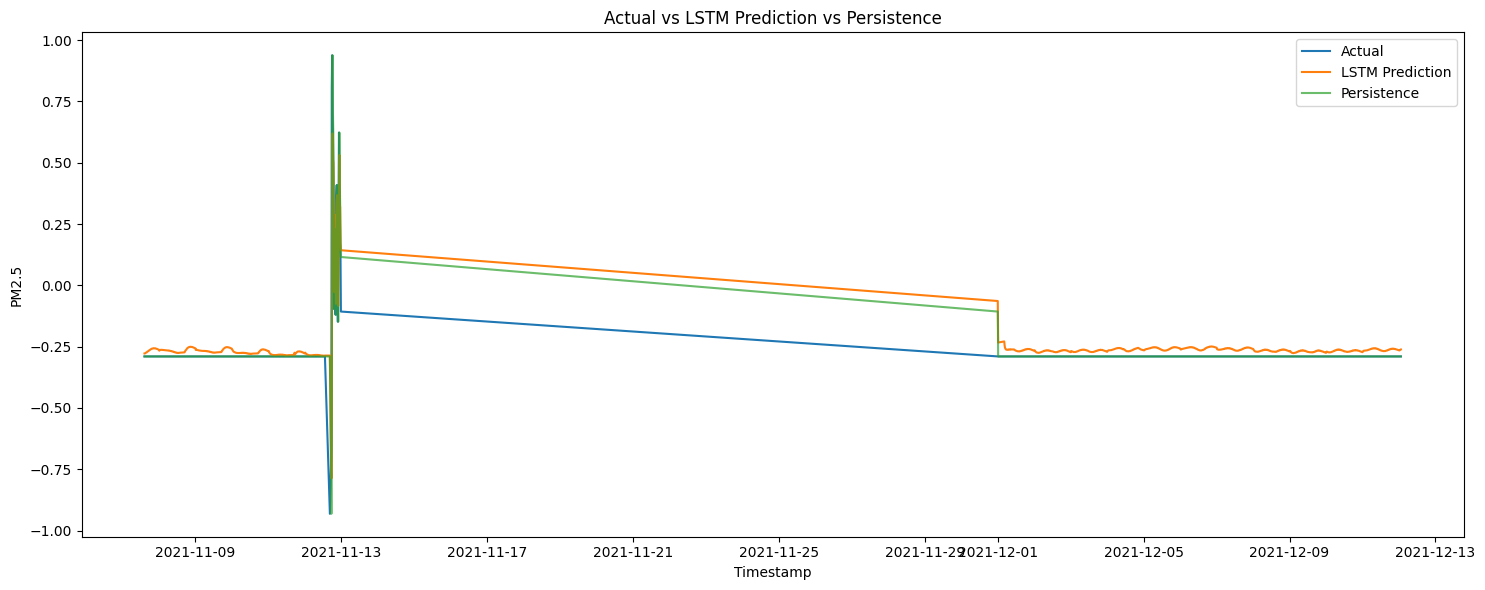

In [76]:
# ============================================================
# 21A. ACTUAL VS PREDICTED
# ============================================================

plot_results = (
    results
    .sort_values("timestamp")
    .iloc[
        :min(
            1500,
            len(results)
        )
    ]
)


plt.figure(figsize=(15, 6))


plt.plot(
    plot_results["timestamp"],
    plot_results["actual"],
    label="Actual"
)


plt.plot(
    plot_results["timestamp"],
    plot_results["predicted"],
    label="LSTM Prediction"
)


plt.plot(
    plot_results["timestamp"],
    plot_results["persistence"],
    label="Persistence",
    alpha=0.7
)


plt.title(
    "Actual vs LSTM Prediction vs Persistence"
)

plt.xlabel("Timestamp")
plt.ylabel(TARGET)

plt.legend()

plt.tight_layout()
plt.show()


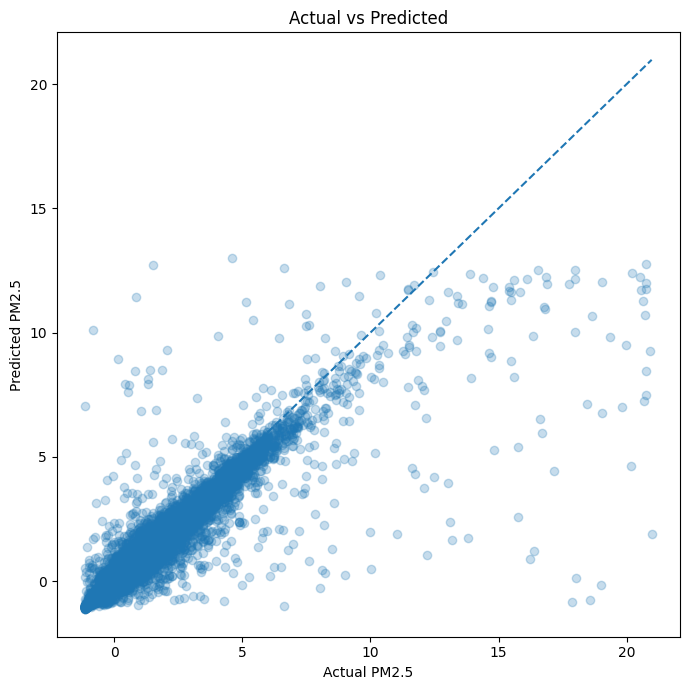

In [77]:
# ============================================================
# 21B. ACTUAL VS PREDICTED SCATTER
# ============================================================

plt.figure(figsize=(7, 7))


plt.scatter(
    y_true,
    y_pred,
    alpha=0.25
)


minimum = min(
    y_true.min(),
    y_pred.min()
)

maximum = max(
    y_true.max(),
    y_pred.max()
)


plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)


plt.xlabel(
    f"Actual {TARGET}"
)

plt.ylabel(
    f"Predicted {TARGET}"
)

plt.title(
    "Actual vs Predicted"
)

plt.tight_layout()
plt.show()


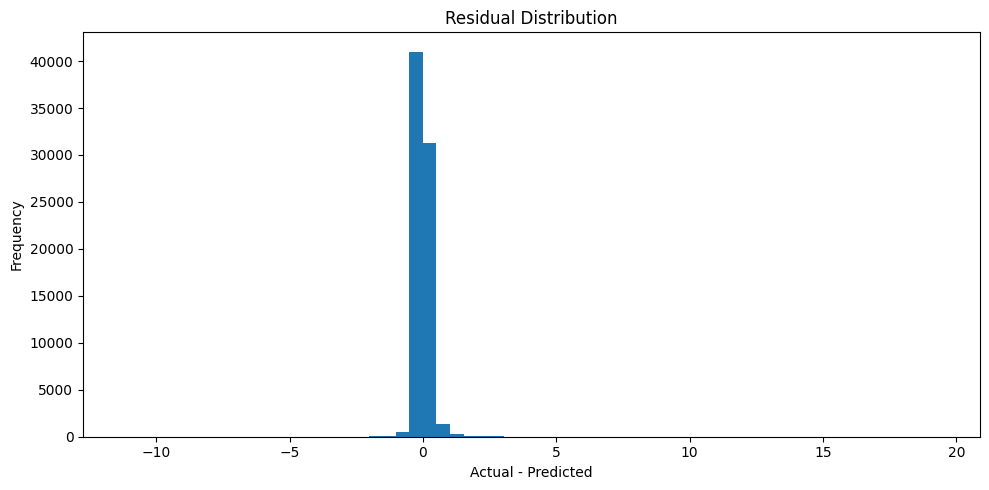

In [78]:
# ============================================================
# 21C. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))


plt.hist(
    results["residual"],
    bins=60
)


plt.title(
    "Residual Distribution"
)

plt.xlabel(
    "Actual - Predicted"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()


## 22. Location-wise evaluation

In [79]:
# ============================================================
# 22. LOCATION-WISE METRICS
# ============================================================

location_metrics = []


for location, group in results.groupby(
    "location"
):

    actual = (
        group["actual"]
        .to_numpy()
    )

    predicted = (
        group["predicted"]
        .to_numpy()
    )

    persistence = (
        group["persistence"]
        .to_numpy()
    )


    location_metrics.append({

        "location": location,

        "samples": len(group),

        "LSTM_MAE": mean_absolute_error(
            actual,
            predicted
        ),

        "LSTM_RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),

        "LSTM_R2": r2_score(
            actual,
            predicted
        ),

        "Persistence_MAE": mean_absolute_error(
            actual,
            persistence
        ),

        "Persistence_RMSE": np.sqrt(
            mean_squared_error(
                actual,
                persistence
            )
        )
    })


location_metrics_df = (
    pd.DataFrame(
        location_metrics
    )
    .sort_values(
        "LSTM_RMSE"
    )
    .reset_index(drop=True)
)


location_metrics_df["MAE_Improvement"] = (

    location_metrics_df["Persistence_MAE"]

    - location_metrics_df["LSTM_MAE"]
)


display(
    location_metrics_df.round(4)
)


,location,samples,LSTM_MAE,LSTM_RMSE,LSTM_R2,Persistence_MAE,Persistence_RMSE,MAE_Improvement
0,BandraMumbaiMPCB,1590,0.0280,0.0515,0.6020,0.0044,0.0481,-0.0236
1,BorivaliEastMumbaiMPCB,3454,0.0830,0.1220,0.9594,0.0552,0.1188,-0.0278
2,VasaiWestMumbaiMPCB,3144,0.0820,0.1291,0.9358,0.0602,0.1341,-0.0218
3,WorliMumbaiMPCB,3863,0.0875,0.1337,0.9544,0.0533,0.1247,-0.0342
4,ChhatrapatiShivajiIntlAirportT2MumbaiMPCB,4026,0.0840,0.1377,0.9317,0.0534,0.1352,-0.0306
5,ChakalaAndheriEastMumbaiIITM,3923,0.0894,0.1494,0.9671,0.0873,0.1690,-0.0021
6,PowaiMumbaiMPCB,4382,0.0894,0.1504,0.9602,0.0662,0.1546,-0.0232
7,MaladWestMumbaiIITM,3349,0.1056,0.1513,0.9535,0.0815,0.1551,-0.0241
8,KurlaMumbaiMPCB,3292,0.0960,0.1696,0.8895,0.0575,0.1787,-0.0384
9,BorivaliEastMumbaiIITM,2857,0.0912,0.1825,0.9567,0.0628,0.1888,-0.0284


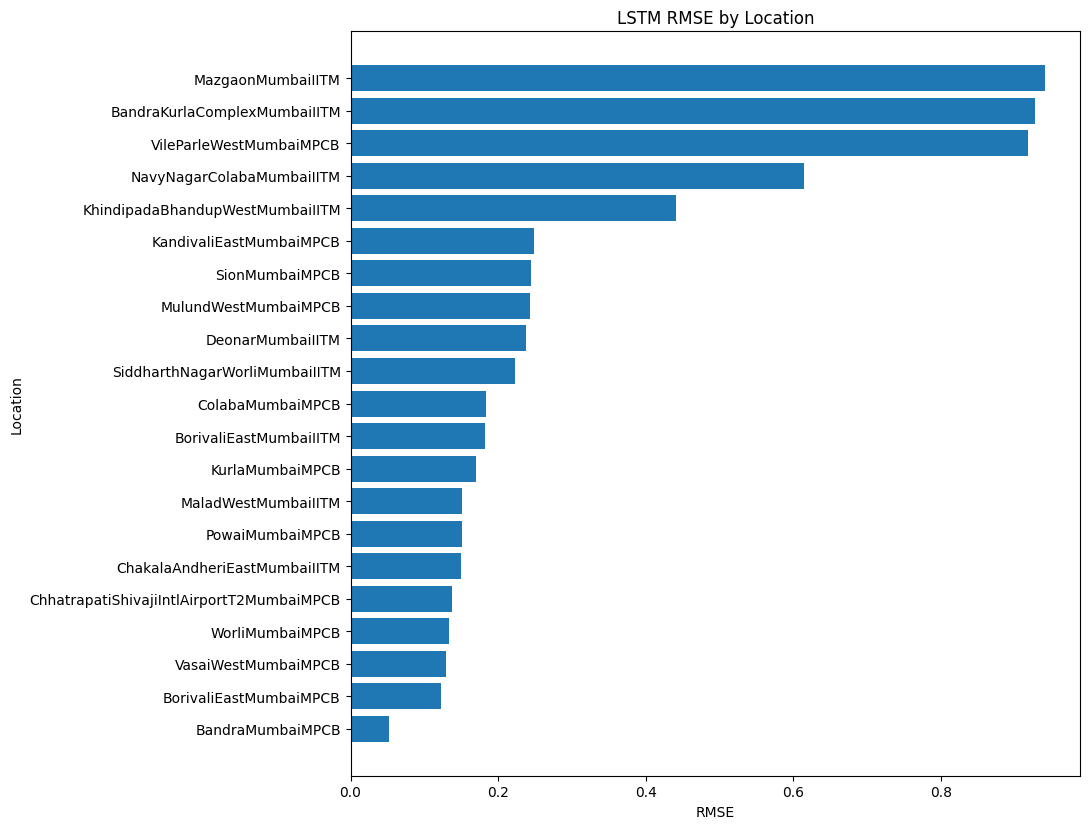

In [80]:
# ============================================================
# 22A. LOCATION-WISE RMSE
# ============================================================

plot_metrics = (
    location_metrics_df
    .sort_values(
        "LSTM_RMSE"
    )
)


plt.figure(
    figsize=(
        11,
        max(
            6,
            len(plot_metrics)
            * 0.4
        )
    )
)


plt.barh(
    plot_metrics["location"],
    plot_metrics["LSTM_RMSE"]
)


plt.title(
    "LSTM RMSE by Location"
)

plt.xlabel("RMSE")
plt.ylabel("Location")

plt.tight_layout()
plt.show()


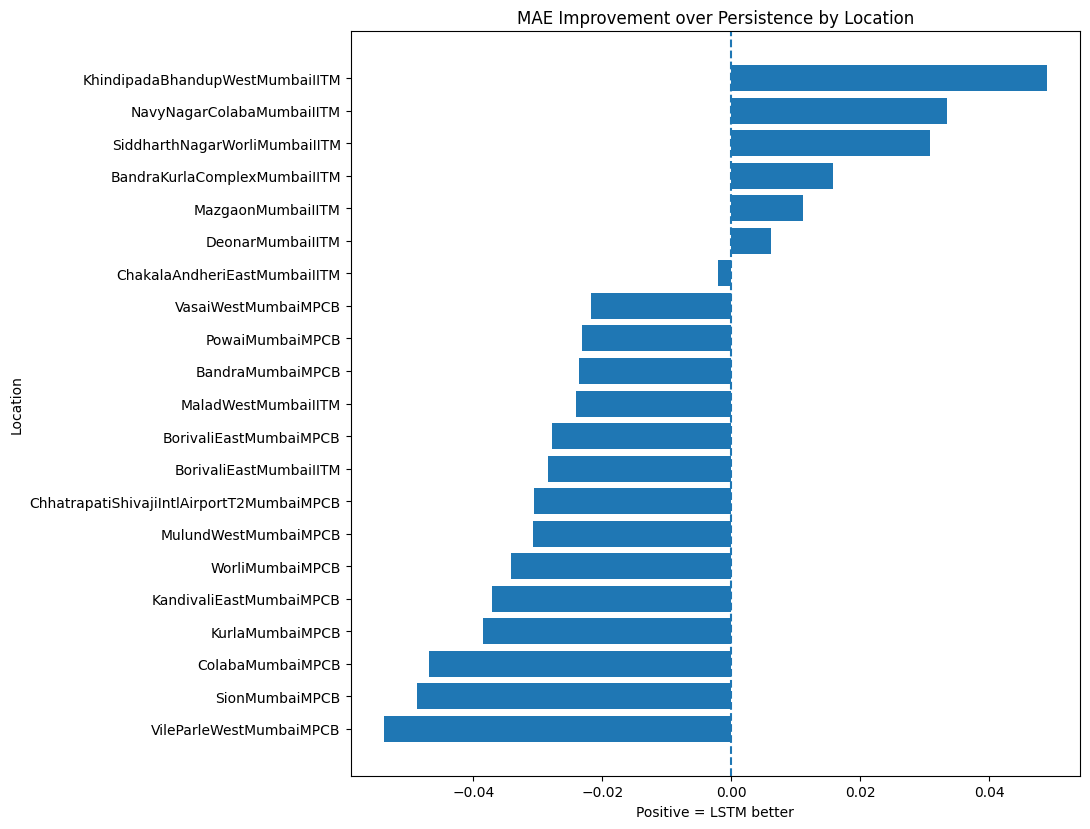

In [81]:
# ============================================================
# 22B. LSTM MAE IMPROVEMENT VS BASELINE
# ============================================================

plot_metrics = (
    location_metrics_df
    .sort_values(
        "MAE_Improvement"
    )
)


plt.figure(
    figsize=(
        11,
        max(
            6,
            len(plot_metrics)
            * 0.4
        )
    )
)


plt.barh(
    plot_metrics["location"],
    plot_metrics["MAE_Improvement"]
)


plt.axvline(
    0,
    linestyle="--"
)


plt.title(
    "MAE Improvement over Persistence by Location"
)

plt.xlabel(
    "Positive = LSTM better"
)

plt.ylabel("Location")

plt.tight_layout()
plt.show()


## 23. Plot a single location

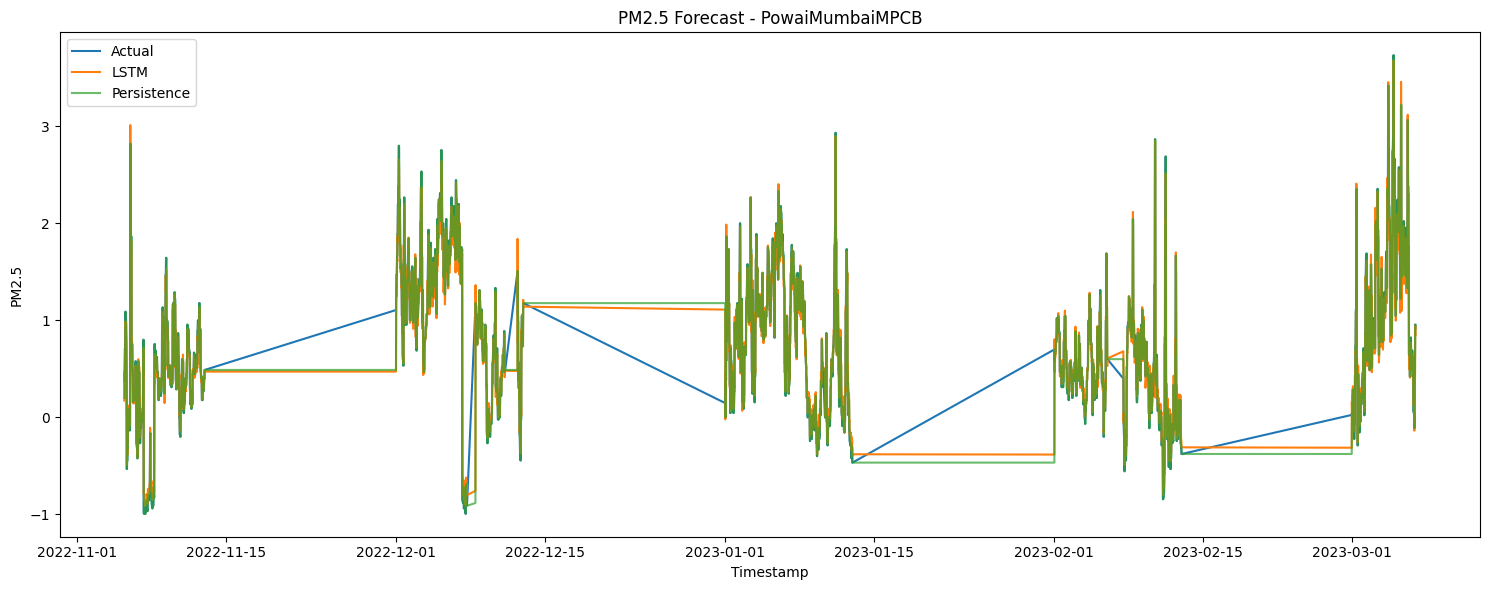

Location: PowaiMumbaiMPCB


In [82]:
# ============================================================
# 23. SINGLE LOCATION PLOT
# ============================================================

# Change this to any location you want.
LOCATION_TO_PLOT = (
    results["location"]
    .value_counts()
    .index[0]
)


location_results = (
    results[
        results["location"]
        == LOCATION_TO_PLOT
    ]
    .sort_values("timestamp")
)


plt.figure(
    figsize=(15, 6)
)


plt.plot(
    location_results["timestamp"],
    location_results["actual"],
    label="Actual"
)


plt.plot(
    location_results["timestamp"],
    location_results["predicted"],
    label="LSTM"
)


plt.plot(
    location_results["timestamp"],
    location_results["persistence"],
    label="Persistence",
    alpha=0.7
)


plt.title(
    f"{TARGET} Forecast - "
    f"{LOCATION_TO_PLOT}"
)


plt.xlabel("Timestamp")
plt.ylabel(TARGET)

plt.legend()

plt.tight_layout()
plt.show()


print(
    "Location:",
    LOCATION_TO_PLOT
)


## 24. Inspect errors during high-pollution events

In [83]:
# ============================================================
# 24. ERROR BY TARGET MAGNITUDE
# ============================================================

results["target_bin"] = pd.qcut(
    results["actual"],
    q=5,
    duplicates="drop"
)


error_by_bin = (
    results
    .groupby(
        "target_bin",
        observed=False
    )
    .agg(

        samples=(
            "actual",
            "size"
        ),

        mean_actual=(
            "actual",
            "mean"
        ),

        MAE=(
            "absolute_error",
            "mean"
        )
    )
)


display(
    error_by_bin.round(4)
)


,samples,mean_actual,MAE
target_bin,,,
"(-1.1349999999999998, -0.0948]",14990,-0.4393,0.0893
"(-0.0948, 0.377]",15246,0.1500,0.0877
"(0.377, 0.799]",14753,0.5873,0.0888
"(0.799, 1.487]",15040,1.1013,0.1207
"(1.487, 20.977]",14899,2.5945,0.3075


## 25. Save model and artifacts

In [84]:
# ============================================================
# 25. SAVE MODEL CHECKPOINT
# ============================================================

model_path = (
    OUTPUT_DIR
    / "mumbai_pm25_lstm_pytorch.pt"
)


checkpoint = {

    "model_state_dict": (
        model.state_dict()
    ),

    "input_size": len(FEATURES),

    "hidden_size": HIDDEN_SIZE,

    "num_layers": NUM_LAYERS,

    "dropout": DROPOUT,

    "sequence_length": SEQUENCE_LENGTH,

    "forecast_horizon": FORECAST_HORIZON,

    "target": TARGET,

    "features": FEATURES,

    "pollutant_features": POLLUTANT_FEATURES,

    "time_features": TIME_FEATURES,

    "missing_indicators": MISSING_INDICATORS,

    "best_validation_loss": float(
        best_val_loss
    )
}


torch.save(
    checkpoint,
    model_path
)


joblib.dump(

    feature_scaler,

    OUTPUT_DIR
    / "feature_scaler.pkl"
)


joblib.dump(

    target_scaler,

    OUTPUT_DIR
    / "target_scaler.pkl"
)


results.to_csv(

    OUTPUT_DIR
    / "test_predictions.csv",

    index=False
)


location_metrics_df.to_csv(

    OUTPUT_DIR
    / "location_metrics.csv",

    index=False
)


comparison_df.to_csv(

    OUTPUT_DIR
    / "model_vs_baseline.csv",

    index=False
)


metrics_df.to_csv(

    OUTPUT_DIR
    / "test_metrics.csv",

    index=False
)


In [85]:
# ============================================================
# 25A. SAVE CONFIGURATION
# ============================================================

config = {

    "framework": "PyTorch",

    "device": str(DEVICE),

    "target": TARGET,

    "sequence_length": SEQUENCE_LENGTH,

    "forecast_horizon": FORECAST_HORIZON,

    "features": FEATURES,

    "pollutant_features": POLLUTANT_FEATURES,

    "time_features": TIME_FEATURES,

    "missing_indicators": MISSING_INDICATORS,

    "train_ratio": TRAIN_RATIO,

    "validation_ratio": VAL_RATIO,

    "test_ratio": TEST_RATIO,

    "best_validation_loss": float(
        best_val_loss
    ),

    "test_metrics": {

        "MAE": float(lstm_mae),

        "RMSE": float(lstm_rmse),

        "R2": float(lstm_r2),

        "Median_AE": float(
            lstm_median_ae
        ),

        "sMAPE": float(
            lstm_smape
        )
    }
}


with open(
    OUTPUT_DIR
    / "config.json",
    "w"
) as file:

    json.dump(
        config,
        file,
        indent=4
    )


print(
    "Saved artifacts:"
)


for file_path in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        " -",
        file_path.name
    )


Saved artifacts:
 - config.json
 - feature_scaler.pkl
 - location_metrics.csv
 - model_vs_baseline.csv
 - mumbai_pm25_lstm_pytorch.pt
 - target_scaler.pkl
 - test_metrics.csv
 - test_predictions.csv


# Final Summary

## Mumbai Air Quality Forecasting using PyTorch LSTM

This project implements a **multivariate Long Short-Term Memory (LSTM) model using PyTorch** to forecast **PM2.5 concentrations across multiple air-quality monitoring locations in Mumbai**. The dataset consists of separate CSV files for different locations and includes pollutant measurements such as PM2.5, PM10, NO, NO2, NOx, NH3, SO2, and CO.

The final pipeline was designed to address several important challenges in real-world time-series forecasting, including **missing sensor values, inconsistent data quality, multiple locations, temporal leakage, and highly skewed pollution values**.

---

## Data Processing

All CSV files from the dataset were combined while preserving the monitoring location of each observation. Timestamps were parsed and the data was sorted chronologically for every location.

The following pollutant variables were used whenever available:

- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- SO2
- CO
- O3

Negative pollutant concentrations were treated as invalid measurements and converted to missing values.

Instead of dropping pollutant features because of missing values, the pipeline retained them and added **missingness indicators**. This allows the LSTM to learn whether the absence of a sensor measurement itself contains useful information.

---

## Feature Engineering

The final model uses three categories of features.

### 1. Pollutant Features

Historical values of air pollutants, including PM2.5 itself, were used as multivariate input features.

### 2. Temporal Features

Cyclical time features were created to capture periodic air pollution patterns:

- Hour of day
- Day of week
- Month of year

These were represented using sine and cosine transformations:

- `hour_sin`, `hour_cos`
- `dow_sin`, `dow_cos`
- `month_sin`, `month_cos`

This representation allows the model to understand the cyclical relationship between time periods such as 23:00 and 00:00.

### 3. Missingness Indicators

For every pollutant feature, an additional binary variable was created indicating whether the original measurement was missing.

---

## Missing Value Strategy

One of the major improvements in the final pipeline was the removal of potentially problematic interpolation methods.

The final implementation uses **causal imputation**, meaning that missing values are filled using only information available from the past.

The strategy was:

1. Use the current observed value if available.
2. Otherwise, use the most recent known value from the past.
3. If no historical value exists, use a fallback median calculated from the training data.

The pipeline does not use:

- Backward filling
- Future interpolation
- Future observations

This reduces the risk of **temporal data leakage** and produces a more realistic forecasting experiment.

---

## Train, Validation and Test Split

The data was split chronologically for every monitoring location.

- **70% Training**
- **15% Validation**
- **15% Testing**

Random splitting was avoided because it would allow information from the future to appear in the training data.

Sequences were generated independently for every location, ensuring that observations from one monitoring station were never mixed with another station.

A sequence length of **24 previous observations** was used to predict the next PM2.5 value.

---

## Model Architecture

The forecasting model was implemented using **PyTorch**.

The architecture consists of:

- Two LSTM layers
- Hidden size of 128
- Dropout for regularization
- Fully connected regression layers
- AdamW optimizer
- Mean Squared Error loss
- Gradient clipping
- Learning rate scheduling
- Early stopping

The model learns temporal relationships between historical pollutant concentrations and time-based features to predict future PM2.5 concentrations.

---

## Model Performance

The final model achieved the following results on the held-out test set:

| Metric | Value |
|---|---:|
| MAE | **0.1386** |
| RMSE | **0.4282** |
| R² | **0.8839** |
| Median Absolute Error | **0.0705** |
| sMAPE | **28.10%** |

### Interpretation

The model achieved an **R² score of 0.8839**, indicating that it explains approximately **88.4% of the variation in PM2.5 concentrations** on the test dataset.

The **Median Absolute Error of 0.0705** is significantly lower than the MAE of 0.1386, indicating that most predictions are highly accurate while a smaller number of observations produce larger errors.

The difference between MAE and RMSE suggests that the model performs well under normal pollution conditions but experiences larger prediction errors during certain events, potentially corresponding to sudden pollution spikes or unusual atmospheric conditions.

---

## Why sMAPE Was Used Instead of MAPE

Ordinary Mean Absolute Percentage Error (MAPE) produced an unrealistically high value because PM2.5 values can occasionally be close to zero.

For example, a small absolute prediction error can result in an extremely large percentage error when the actual PM2.5 value is close to zero.

Therefore, **Symmetric Mean Absolute Percentage Error (sMAPE)** was used instead. The final sMAPE value of **28.10%** provides a more stable percentage-based evaluation.

---

## Baseline Comparison

The LSTM model was compared with a **persistence baseline**.

The persistence model assumes:

> The next PM2.5 value will be equal to the most recent PM2.5 observation.

This comparison is important because air pollution data often exhibits strong temporal autocorrelation. A deep learning model should demonstrate improvement over this simple baseline to justify its additional complexity.

---

## Key Strengths of the Final Pipeline

The final implementation includes several important improvements:

- Uses data from multiple Mumbai monitoring locations.
- Uses multivariate pollutant information.
- Preserves missingness information instead of simply dropping features.
- Uses leakage-safe causal imputation.
- Avoids backward filling and future interpolation.
- Uses chronological time-series splitting.
- Prevents sequences from mixing different locations.
- Fits scalers only on training data.
- Explicitly checks for NaN and infinite values.
- Uses early stopping and learning-rate scheduling.
- Uses gradient clipping for stable LSTM training.
- Evaluates performance using multiple metrics.
- Uses sMAPE instead of unreliable ordinary MAPE.
- Compares the model against a persistence baseline.
- Supports location-wise performance analysis.

---

## Conclusion

The final PyTorch LSTM model demonstrates **strong predictive performance for PM2.5 forecasting across Mumbai monitoring locations**, achieving an R² score of **0.8839** with a low median absolute error of **0.0705**.

The results indicate that the model successfully learns temporal patterns from historical pollutant concentrations and cyclical time features. The relatively higher RMSE compared with MAE suggests that sudden or extreme pollution events remain more difficult to predict, which is expected given the right-skewed nature of PM2.5 concentrations.

Overall, the project provides a **robust and leakage-aware deep learning pipeline for multi-location air pollution forecasting**.

Future improvements could include:

- Applying a `log1p(PM2.5)` transformation to better handle the right-skewed target distribution.
- Comparing LSTM with GRU and Transformer-based models.
- Adding meteorological variables such as temperature, humidity, rainfall, and wind speed.
- Training location-specific models and comparing them with the global model.
- Forecasting multiple future horizons instead of only the next observation.
- Constructing an official AQI target using pollutant breakpoint calculations.
- Performing hyperparameter optimization for sequence length, hidden size, and learning rate.